In [2]:
from pathlib import Path
import hashlib

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        has_root_files = (candidate / "train.csv").exists() and (candidate / "test.csv").exists()
        has_data_files = (candidate / "data" / "train.csv").exists() and (candidate / "data" / "test.csv").exists()
        if has_root_files or has_data_files:
            return candidate
    raise FileNotFoundError("Could not locate project root.")


PROJECT_ROOT = find_project_root()


def resolve_data_path(filename: str) -> Path:
    for path in [PROJECT_ROOT / filename, PROJECT_ROOT / "data" / filename]:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {filename} in project root or data/")


train = pd.read_csv(resolve_data_path("train.csv"), parse_dates=["date"])
test = pd.read_csv(resolve_data_path("test.csv"), parse_dates=["date"])

train_date_summary = (
    train.groupby("date")
    .agg(
        total_rows=("row_id", "size"),
        observed_rows=("iv_observed", lambda s: s.notna().sum()),
        missing_rows=("iv_observed", lambda s: s.isna().sum()),
        observed_ratio=("iv_observed", lambda s: s.notna().mean()),
    )
    .sort_index()
)

train_dates = train_date_summary.index.to_list()

N_FOLDS = 4
VAL_DATES_PER_FOLD = 5
TOTAL_VAL_DATES = N_FOLDS * VAL_DATES_PER_FOLD
val_start_idx = len(train_dates) - TOTAL_VAL_DATES

fold_plan = pd.DataFrame(
    [
        {
            "fold": fold_id + 1,
            "train_start": train_dates[0],
            "train_end": train_dates[val_start_idx + fold_id * VAL_DATES_PER_FOLD - 1],
            "n_train_dates": val_start_idx + fold_id * VAL_DATES_PER_FOLD,
            "val_start": train_dates[val_start_idx + fold_id * VAL_DATES_PER_FOLD],
            "val_end": train_dates[val_start_idx + (fold_id + 1) * VAL_DATES_PER_FOLD - 1],
            "n_val_dates": VAL_DATES_PER_FOLD,
        }
        for fold_id in range(N_FOLDS)
    ]
)

print("Project root:", PROJECT_ROOT)
display(fold_plan)


Project root: /Users/sauravkrishna/Documents/projects/NQFO-Impilied-volatility-surface


,fold,train_start,train_end,n_train_dates,val_start,val_end,n_val_dates
0,1,2025-01-02,2025-04-18,77,2025-04-21,2025-04-25,5
1,2,2025-01-02,2025-04-25,82,2025-04-28,2025-05-02,5
2,3,2025-01-02,2025-05-02,87,2025-05-05,2025-05-09,5
3,4,2025-01-02,2025-05-09,92,2025-05-12,2025-05-16,5


In [3]:
BUCKET_COLS = ["maturity_label", "option_type"]
NODE_COLS = ["maturity_label", "moneyness", "option_type"]

MASK_PROTOCOL_CONFIG = {
    "stress_test": {
        "base_hide_rate": 0.10,
        "node_weight": 1.00,
        "support_weight": 0.00,
    },
    "primary_realistic": {
        "base_hide_rate": 0.10,
        "node_weight": 0.65,
        "support_weight": 0.35,
    },
}
LOCKED_MASK_SEED = "nqfo-val-v1"

OVERALL_TEST_MISSING_RATE = test["iv_observed"].isna().mean()

test_bucket_pattern = (
    test.assign(is_missing=test["iv_observed"].isna())
    .groupby(BUCKET_COLS)["is_missing"]
    .mean()
    .rename("test_bucket_missing_rate")
    .reset_index()
)

test_node_pattern = (
    test.assign(is_missing=test["iv_observed"].isna())
    .groupby(NODE_COLS)["is_missing"]
    .mean()
    .rename("test_node_missing_rate")
    .reset_index()
)

surface_levels = pd.concat(
    [
        train[["moneyness", "maturity_label", "maturity_days"]],
        test[["moneyness", "maturity_label", "maturity_days"]],
    ],
    ignore_index=True,
)

moneyness_levels = sorted(surface_levels["moneyness"].dropna().unique().tolist())
maturity_levels = (
    surface_levels[["maturity_label", "maturity_days"]]
    .drop_duplicates()
    .sort_values("maturity_days")["maturity_label"]
    .tolist()
)

m_idx = {m: i for i, m in enumerate(moneyness_levels)}
t_idx = {t: i for i, t in enumerate(maturity_levels)}


def stable_uniform(key: str) -> float:
    digest = hashlib.md5(key.encode("utf-8")).hexdigest()
    return int(digest[:12], 16) / float(16**12 - 1)


def opposite_option(opt: str) -> str:
    return "put" if opt == "call" else "call"


def local_support_profile(target_rows: pd.DataFrame, visible_rows: pd.DataFrame) -> pd.DataFrame:
    prof = target_rows.copy()

    visible_key_set = set(
        zip(
            visible_rows["date"],
            visible_rows["moneyness"],
            visible_rows["maturity_label"],
            visible_rows["option_type"],
        )
    )

    opp_visible = []
    same_maturity_adj_count = []
    same_moneyness_adj_count = []

    for d, m, t, o in zip(
        prof["date"],
        prof["moneyness"],
        prof["maturity_label"],
        prof["option_type"],
    ):
        opp_visible.append((d, m, t, opposite_option(o)) in visible_key_set)

        i = m_idx[m]
        j = t_idx[t]

        same_maturity_candidates = []
        if i - 1 >= 0:
            same_maturity_candidates.append((d, moneyness_levels[i - 1], t, o))
        if i + 1 < len(moneyness_levels):
            same_maturity_candidates.append((d, moneyness_levels[i + 1], t, o))

        same_moneyness_candidates = []
        if j - 1 >= 0:
            same_moneyness_candidates.append((d, m, maturity_levels[j - 1], o))
        if j + 1 < len(maturity_levels):
            same_moneyness_candidates.append((d, m, maturity_levels[j + 1], o))

        same_maturity_adj_count.append(sum(c in visible_key_set for c in same_maturity_candidates))
        same_moneyness_adj_count.append(sum(c in visible_key_set for c in same_moneyness_candidates))

    prof["opp_option_visible"] = opp_visible
    prof["same_maturity_adj_visible_count"] = same_maturity_adj_count
    prof["same_moneyness_adj_visible_count"] = same_moneyness_adj_count
    prof["local_support_score"] = (
        prof["opp_option_visible"].astype(int)
        + prof["same_maturity_adj_visible_count"]
        + prof["same_moneyness_adj_visible_count"]
    )
    return prof


def build_masked_validation_rows_with_protocol(
    full_df: pd.DataFrame,
    val_dates,
    protocol_name: str,
    seed: str = LOCKED_MASK_SEED,
) -> pd.DataFrame:
    cfg = MASK_PROTOCOL_CONFIG[protocol_name]

    val_df = full_df.loc[full_df["date"].isin(val_dates)].copy()
    val_df["is_orig_observed"] = val_df["iv_observed"].notna()
    val_df["is_orig_missing"] = ~val_df["is_orig_observed"]

    val_df = val_df.merge(test_bucket_pattern, on=BUCKET_COLS, how="left")
    val_df = val_df.merge(test_node_pattern, on=NODE_COLS, how="left")

    val_df["bucket_hide_rate_on_observed"] = (
        cfg["base_hide_rate"] * val_df["test_bucket_missing_rate"] / OVERALL_TEST_MISSING_RATE
    )

    val_df["priority_noise"] = val_df.apply(
        lambda r: stable_uniform(
            f"{seed}|{protocol_name}|{r['date'].date()}|{r['maturity_label']}|{r['moneyness']:.4f}|{r['option_type']}"
        ),
        axis=1,
    )

    observed_pool = val_df.loc[val_df["is_orig_observed"]].copy()
    observed_support = local_support_profile(observed_pool, observed_pool)[["row_id", "local_support_score"]]
    val_df = val_df.merge(observed_support, on="row_id", how="left")
    val_df["local_support_score"] = val_df["local_support_score"].fillna(0).astype(int)

    val_df["is_pseudo_hidden"] = False

    observed_pool = val_df.loc[val_df["is_orig_observed"]].copy()
    for _, g in observed_pool.groupby(["date", *BUCKET_COLS], sort=False):
        n_obs = len(g)
        n_hide = int(np.round(g["bucket_hide_rate_on_observed"].iloc[0] * n_obs))
        if n_hide <= 0:
            continue

        node_rank = g["test_node_missing_rate"].rank(method="average", pct=True)
        support_rank = g["local_support_score"].rank(method="average", pct=True)

        selection_priority = (
            cfg["node_weight"] * node_rank
            + cfg["support_weight"] * support_rank
            + 1e-6 * g["priority_noise"]
        )

        chosen_idx = (
            g.assign(selection_priority=selection_priority)
            .sort_values(["selection_priority", "row_id"], ascending=[False, True])
            .head(n_hide)
            .index
        )
        val_df.loc[chosen_idx, "is_pseudo_hidden"] = True

    val_df["is_scored_target"] = val_df["is_pseudo_hidden"]
    val_df["is_visible_anchor"] = val_df["is_orig_observed"] & ~val_df["is_pseudo_hidden"]
    val_df["is_effectively_missing"] = val_df["is_orig_missing"] | val_df["is_pseudo_hidden"]
    val_df["mask_protocol"] = protocol_name

    return val_df.sort_values(["date", "maturity_days", "option_type", "moneyness"]).reset_index(drop=True)


def make_fold_bundle_for_protocol(train_df: pd.DataFrame, fold_row, protocol_name: str):
    val_dates = train_date_summary.loc[fold_row.val_start:fold_row.val_end].index.tolist()
    train_dates = train_date_summary.loc[:fold_row.train_end].index.tolist()

    train_history = train_df.loc[train_df["date"].isin(train_dates)].copy()
    val_masked = build_masked_validation_rows_with_protocol(train_df, val_dates, protocol_name)

    return {
        "fold": fold_row.fold,
        "protocol": protocol_name,
        "train_history": train_history,
        "val_masked": val_masked,
        "val_visible_anchors": val_masked.loc[val_masked["is_visible_anchor"]].copy(),
        "val_scored_targets": val_masked.loc[val_masked["is_scored_target"]].copy(),
    }


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float))))


def score_predictions(scored_df: pd.DataFrame, pred_col: str = "iv_pred") -> dict:
    eval_df = scored_df.loc[scored_df["is_scored_target"]].copy()
    eval_df = eval_df.loc[eval_df["iv_observed"].notna() & eval_df[pred_col].notna()].copy()
    return {
        "n_scored": len(eval_df),
        "rmse": rmse(eval_df["iv_observed"], eval_df[pred_col]),
    }


In [4]:
def build_node_lookup(observed_df: pd.DataFrame, pred_name: str) -> pd.DataFrame:
    return (
        observed_df.groupby(NODE_COLS)["iv_observed"]
        .median()
        .rename(pred_name)
        .reset_index()
    )


def predict_recent_node_median(
    train_history: pd.DataFrame,
    val_masked: pd.DataFrame,
    lookback_dates: int = 20,
) -> pd.DataFrame:
    out = val_masked.copy()

    observed_train = train_history.loc[train_history["iv_observed"].notna()].copy()
    global_median = observed_train["iv_observed"].median()

    recent_dates = sorted(observed_train["date"].unique())[-lookback_dates:]
    recent_obs = observed_train.loc[observed_train["date"].isin(recent_dates)].copy()

    recent_lookup = build_node_lookup(recent_obs, "recent_node_pred")
    full_lookup = build_node_lookup(observed_train, "full_node_pred")

    out = out.merge(recent_lookup, on=NODE_COLS, how="left")
    out = out.merge(full_lookup, on=NODE_COLS, how="left")

    out["iv_pred"] = out["recent_node_pred"].fillna(out["full_node_pred"]).fillna(global_median)
    out["pred_source"] = np.select(
        [
            out["recent_node_pred"].notna(),
            out["full_node_pred"].notna(),
        ],
        [
            "recent_node_median",
            "full_node_median",
        ],
        default="global_median",
    )
    return out


def predict_same_date_linear_interp(
    train_history: pd.DataFrame,
    val_masked: pd.DataFrame,
    lookback_dates: int = 20,
) -> pd.DataFrame:
    out = predict_recent_node_median(train_history, val_masked, lookback_dates=lookback_dates).copy()

    out["interp_pred"] = np.nan
    out["interp_source"] = pd.Series(index=out.index, dtype="object")

    for (_, maturity_label, option_type), g_idx in out.groupby(
        ["date", "maturity_label", "option_type"], sort=False
    ).groups.items():
        g = out.loc[g_idx].copy()

        anchors = (
            g.loc[g["is_visible_anchor"], ["moneyness", "iv_observed"]]
            .dropna()
            .sort_values("moneyness")
        )

        if len(anchors) == 0:
            continue

        x = anchors["moneyness"].to_numpy()
        y = anchors["iv_observed"].to_numpy()

        if len(anchors) == 1:
            interp_vals = np.repeat(y[0], len(g))
            interp_label = "same_date_single_anchor"
        else:
            interp_vals = np.interp(g["moneyness"].to_numpy(), x, y)
            interp_label = "same_date_linear_interp"

        out.loc[g.index, "interp_pred"] = interp_vals
        out.loc[g.index, "interp_source"] = interp_label

    use_interp = out["interp_pred"].notna()
    out.loc[use_interp, "iv_pred"] = out.loc[use_interp, "interp_pred"]
    out["pred_source"] = np.where(use_interp, out["interp_source"], out["pred_source"])

    return out


def evaluate_baseline(protocol_name: str, predictor_fn, baseline_name: str) -> pd.DataFrame:
    rows = []
    for row in fold_plan.itertuples(index=False):
        bundle = make_fold_bundle_for_protocol(train, row, protocol_name)
        scored = predictor_fn(bundle["train_history"], bundle["val_masked"])
        metrics = score_predictions(scored, pred_col="iv_pred")
        rows.append(
            {
                "protocol": protocol_name,
                "baseline": baseline_name,
                "fold": row.fold,
                "n_scored": metrics["n_scored"],
                "rmse": metrics["rmse"],
            }
        )
    return pd.DataFrame(rows)


print("Phase 4 setup ready.")


Phase 4 setup ready.


In [5]:
def predict_quadratic_smile_logm(
    train_history: pd.DataFrame,
    val_masked: pd.DataFrame,
    lookback_dates: int = 20,
    degree: int = 2,
    min_anchors: int = 5,
) -> pd.DataFrame:
    # Start from the strongest Phase 3 baseline and only overwrite rows where
    # the structured smile fit is trustworthy.
    out = predict_same_date_linear_interp(
        train_history,
        val_masked,
        lookback_dates=lookback_dates,
    ).copy()

    out["log_moneyness"] = np.log(out["moneyness"])
    out["smile_pred"] = np.nan
    out["smile_anchor_count"] = 0
    out["pred_source_smile"] = pd.Series(index=out.index, dtype="object")

    observed_train = train_history.loc[train_history["iv_observed"].notna(), "iv_observed"]
    pred_lo = observed_train.quantile(0.001)
    pred_hi = observed_train.quantile(0.999)

    for (_, maturity_label, option_type), g_idx in out.groupby(
        ["date", "maturity_label", "option_type"], sort=False
    ).groups.items():
        g = out.loc[g_idx].copy()

        anchors = (
            g.loc[g["is_visible_anchor"], ["log_moneyness", "iv_observed"]]
            .dropna()
            .sort_values("log_moneyness")
        )

        if len(anchors) < min_anchors:
            continue
        if anchors["log_moneyness"].nunique() < degree + 1:
            continue

        x = anchors["log_moneyness"].to_numpy()
        y = anchors["iv_observed"].to_numpy()

        x_center = x.mean()
        coeffs = np.polyfit(x - x_center, y, deg=degree)

        target_x = g["log_moneyness"].to_numpy()
        pred = np.polyval(coeffs, target_x - x_center)

        # Only trust the smile fit inside the observed anchor span.
        in_range = (target_x >= x.min()) & (target_x <= x.max())
        pred = np.where(in_range, pred, np.nan)
        pred = np.clip(pred, pred_lo, pred_hi)

        out.loc[g.index, "smile_pred"] = pred
        out.loc[g.index, "smile_anchor_count"] = len(anchors)
        out.loc[g.index, "pred_source_smile"] = np.where(in_range, "quadratic_smile_logm", pd.NA)

    use_smile = out["smile_pred"].notna()
    out.loc[use_smile, "iv_pred"] = out.loc[use_smile, "smile_pred"]
    out["pred_source"] = np.where(use_smile, out["pred_source_smile"], out["pred_source"])

    return out


In [6]:
phase4_results = pd.concat(
    [
        evaluate_baseline(
            "primary_realistic",
            lambda th, vm: predict_same_date_linear_interp(th, vm, lookback_dates=20),
            "same_date_linear_interp",
        ),
        evaluate_baseline(
            "primary_realistic",
            lambda th, vm: predict_quadratic_smile_logm(th, vm, lookback_dates=20),
            "quadratic_smile_logm",
        ),
        evaluate_baseline(
            "stress_test",
            lambda th, vm: predict_same_date_linear_interp(th, vm, lookback_dates=20),
            "same_date_linear_interp",
        ),
        evaluate_baseline(
            "stress_test",
            lambda th, vm: predict_quadratic_smile_logm(th, vm, lookback_dates=20),
            "quadratic_smile_logm",
        ),
    ],
    ignore_index=True,
)

phase4_summary = (
    phase4_results.groupby(["protocol", "baseline"])
    .agg(
        mean_rmse=("rmse", "mean"),
        min_rmse=("rmse", "min"),
        max_rmse=("rmse", "max"),
        mean_n_scored=("n_scored", "mean"),
    )
    .reset_index()
    .sort_values(["protocol", "mean_rmse"])
)

display(phase4_results.sort_values(["protocol", "baseline", "fold"]))
print("Phase 4 first-model comparison")
display(phase4_summary)


,protocol,baseline,fold,n_scored,rmse
4,primary_realistic,quadratic_smile_logm,1,39,1.5698
5,primary_realistic,quadratic_smile_logm,2,38,1.0583
6,primary_realistic,quadratic_smile_logm,3,39,0.8505
7,primary_realistic,quadratic_smile_logm,4,40,1.1934
0,primary_realistic,same_date_linear_interp,1,39,1.5942
1,primary_realistic,same_date_linear_interp,2,38,1.0453
2,primary_realistic,same_date_linear_interp,3,39,0.9115
3,primary_realistic,same_date_linear_interp,4,40,1.1998
12,stress_test,quadratic_smile_logm,1,39,1.5718
13,stress_test,quadratic_smile_logm,2,38,1.3908


Phase 4 first-model comparison


,protocol,baseline,mean_rmse,min_rmse,max_rmse,mean_n_scored
0,primary_realistic,quadratic_smile_logm,1.1680,0.8505,1.5698,39.0000
1,primary_realistic,same_date_linear_interp,1.1877,0.9115,1.5942,39.0000
2,stress_test,quadratic_smile_logm,1.3637,1.2388,1.5718,39.0000
3,stress_test,same_date_linear_interp,1.3975,1.2728,1.5903,39.0000


In [7]:
demo_bundle = make_fold_bundle_for_protocol(train, fold_plan.iloc[0], "primary_realistic")
demo_quad = predict_quadratic_smile_logm(
    demo_bundle["train_history"],
    demo_bundle["val_masked"],
    lookback_dates=20,
)

print("Fold 1 / primary_realistic prediction source mix")
display(
    demo_quad.loc[demo_quad["is_scored_target"], "pred_source"]
    .value_counts(dropna=False)
    .rename_axis("pred_source")
    .to_frame("count")
)

print("Quadratic-fit usage by anchor count on scored rows")
display(
    demo_quad.loc[
        demo_quad["is_scored_target"] & (demo_quad["pred_source"] == "quadratic_smile_logm"),
        "smile_anchor_count",
    ]
    .value_counts()
    .sort_index()
    .rename_axis("smile_anchor_count")
    .to_frame("count")
)


Fold 1 / primary_realistic prediction source mix


,count
pred_source,
quadratic_smile_logm,22
same_date_linear_interp,17


Quadratic-fit usage by anchor count on scored rows


,count
smile_anchor_count,
5,1
6,4
7,5
8,2
9,5
10,3
11,1
12,1


In [8]:
def pooled_fold_predictions(protocol_name: str, baseline_name: str, predictor_fn) -> pd.DataFrame:
    pooled = []
    for row in fold_plan.itertuples(index=False):
        bundle = make_fold_bundle_for_protocol(train, row, protocol_name)
        scored = predictor_fn(bundle["train_history"], bundle["val_masked"]).copy()
        scored["fold"] = row.fold
        scored["protocol"] = protocol_name
        scored["baseline"] = baseline_name
        pooled.append(scored.loc[scored["is_scored_target"]].copy())
    return pd.concat(pooled, ignore_index=True)


def simple_rmse_breakdown(df: pd.DataFrame, group_cols) -> pd.DataFrame:
    if isinstance(group_cols, str):
        group_cols = [group_cols]

    rows = []
    for keys, g in df.groupby(group_cols, observed=True, sort=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: key for col, key in zip(group_cols, keys)}
        row["n"] = len(g)
        row["rmse"] = rmse(g["iv_observed"], g["iv_pred"])
        rows.append(row)

    return pd.DataFrame(rows).sort_values(group_cols).reset_index(drop=True)


pooled_primary_linear = pooled_fold_predictions(
    "primary_realistic",
    "same_date_linear_interp",
    lambda th, vm: predict_same_date_linear_interp(th, vm, lookback_dates=20),
)
pooled_primary_quad = pooled_fold_predictions(
    "primary_realistic",
    "quadratic_smile_logm",
    lambda th, vm: predict_quadratic_smile_logm(th, vm, lookback_dates=20),
)

for df in (pooled_primary_linear, pooled_primary_quad):
    df["wing_center_bucket"] = np.where(
        df["moneyness"].between(0.9, 1.1, inclusive="both"),
        "center",
        "wing",
    )

print("Primary protocol pooled breakdown by maturity")
display(simple_rmse_breakdown(pd.concat([pooled_primary_linear, pooled_primary_quad], ignore_index=True), ["baseline", "maturity_label"]))

print("Primary protocol pooled breakdown by wing/center")
display(simple_rmse_breakdown(pd.concat([pooled_primary_linear, pooled_primary_quad], ignore_index=True), ["baseline", "wing_center_bucket"]))


Primary protocol pooled breakdown by maturity


,baseline,maturity_label,n,rmse
0,quadratic_smile_logm,1M,40,1.1167
1,quadratic_smile_logm,2M,39,1.6810
2,quadratic_smile_logm,3M,39,0.9443
3,quadratic_smile_logm,6M,38,0.8734
4,same_date_linear_interp,1M,40,1.1354
5,same_date_linear_interp,2M,39,1.6705
6,same_date_linear_interp,3M,39,0.9625
7,same_date_linear_interp,6M,38,0.9471


Primary protocol pooled breakdown by wing/center


,baseline,wing_center_bucket,n,rmse
0,quadratic_smile_logm,center,65,0.6465
1,quadratic_smile_logm,wing,91,1.4702
2,same_date_linear_interp,center,65,0.7131
3,same_date_linear_interp,wing,91,1.4734


In [9]:
def predict_total_variance_maturity_interp(
    train_history: pd.DataFrame,
    val_masked: pd.DataFrame,
    lookback_dates: int = 20,
) -> pd.DataFrame:
    # Start from the strong Phase 3 baseline and overwrite rows where
    # total-variance maturity interpolation is trustworthy.
    out = predict_same_date_linear_interp(
        train_history,
        val_masked,
        lookback_dates=lookback_dates,
    ).copy()

    out["anchor_total_variance"] = np.where(
        out["iv_observed"].notna(),
        (out["iv_observed"] / 100.0) ** 2 * out["tau"],
        np.nan,
    )
    out["tv_pred"] = np.nan
    out["tv_anchor_count"] = 0
    out["pred_source_tv"] = pd.Series(index=out.index, dtype="object")

    observed_train = train_history.loc[train_history["iv_observed"].notna(), "iv_observed"]
    pred_lo = observed_train.quantile(0.001)
    pred_hi = observed_train.quantile(0.999)

    for (_, moneyness, option_type), g_idx in out.groupby(
        ["date", "moneyness", "option_type"], sort=False
    ).groups.items():
        g = out.loc[g_idx].copy()

        anchors = (
            g.loc[g["is_visible_anchor"], ["tau", "anchor_total_variance"]]
            .dropna()
            .sort_values("tau")
        )

        if len(anchors) < 2:
            continue

        x = anchors["tau"].to_numpy()
        y = anchors["anchor_total_variance"].to_numpy()
        target_tau = g["tau"].to_numpy()

        in_range = (target_tau >= x.min()) & (target_tau <= x.max())
        pred_tv = np.interp(target_tau, x, y)
        pred_tv = np.where(in_range, pred_tv, np.nan)
        pred_tv = np.where(pred_tv > 0, pred_tv, np.nan)

        pred_iv = 100.0 * np.sqrt(pred_tv / target_tau)
        pred_iv = np.clip(pred_iv, pred_lo, pred_hi)

        out.loc[g.index, "tv_pred"] = pred_iv
        out.loc[g.index, "tv_anchor_count"] = len(anchors)
        out.loc[g.index, "pred_source_tv"] = np.where(in_range, "tv_maturity_interp", pd.NA)

    use_tv = out["tv_pred"].notna()
    out.loc[use_tv, "iv_pred"] = out.loc[use_tv, "tv_pred"]
    out["pred_source"] = np.where(use_tv, out["pred_source_tv"], out["pred_source"])

    return out


In [10]:
phase4_results_b = pd.concat(
    [
        evaluate_baseline(
            "primary_realistic",
            lambda th, vm: predict_same_date_linear_interp(th, vm, lookback_dates=20),
            "same_date_linear_interp",
        ),
        evaluate_baseline(
            "primary_realistic",
            lambda th, vm: predict_quadratic_smile_logm(th, vm, lookback_dates=20),
            "quadratic_smile_logm",
        ),
        evaluate_baseline(
            "primary_realistic",
            lambda th, vm: predict_total_variance_maturity_interp(th, vm, lookback_dates=20),
            "tv_maturity_interp",
        ),
        evaluate_baseline(
            "stress_test",
            lambda th, vm: predict_same_date_linear_interp(th, vm, lookback_dates=20),
            "same_date_linear_interp",
        ),
        evaluate_baseline(
            "stress_test",
            lambda th, vm: predict_quadratic_smile_logm(th, vm, lookback_dates=20),
            "quadratic_smile_logm",
        ),
        evaluate_baseline(
            "stress_test",
            lambda th, vm: predict_total_variance_maturity_interp(th, vm, lookback_dates=20),
            "tv_maturity_interp",
        ),
    ],
    ignore_index=True,
)

phase4_summary_b = (
    phase4_results_b.groupby(["protocol", "baseline"])
    .agg(
        mean_rmse=("rmse", "mean"),
        min_rmse=("rmse", "min"),
        max_rmse=("rmse", "max"),
        mean_n_scored=("n_scored", "mean"),
    )
    .reset_index()
    .sort_values(["protocol", "mean_rmse"])
)

display(phase4_results_b.sort_values(["protocol", "baseline", "fold"]))
print("Phase 4 comparison after adding maturity interpolation")
display(phase4_summary_b)


,protocol,baseline,fold,n_scored,rmse
4,primary_realistic,quadratic_smile_logm,1,39,1.5698
5,primary_realistic,quadratic_smile_logm,2,38,1.0583
6,primary_realistic,quadratic_smile_logm,3,39,0.8505
7,primary_realistic,quadratic_smile_logm,4,40,1.1934
0,primary_realistic,same_date_linear_interp,1,39,1.5942
1,primary_realistic,same_date_linear_interp,2,38,1.0453
2,primary_realistic,same_date_linear_interp,3,39,0.9115
3,primary_realistic,same_date_linear_interp,4,40,1.1998
8,primary_realistic,tv_maturity_interp,1,39,1.3654
9,primary_realistic,tv_maturity_interp,2,38,1.0523


Phase 4 comparison after adding maturity interpolation


,protocol,baseline,mean_rmse,min_rmse,max_rmse,mean_n_scored
2,primary_realistic,tv_maturity_interp,1.1075,0.8925,1.3654,39.0000
0,primary_realistic,quadratic_smile_logm,1.1680,0.8505,1.5698,39.0000
1,primary_realistic,same_date_linear_interp,1.1877,0.9115,1.5942,39.0000
5,stress_test,tv_maturity_interp,1.2782,1.2255,1.3946,39.0000
3,stress_test,quadratic_smile_logm,1.3637,1.2388,1.5718,39.0000
4,stress_test,same_date_linear_interp,1.3975,1.2728,1.5903,39.0000


In [11]:
demo_tv = predict_total_variance_maturity_interp(
    make_fold_bundle_for_protocol(train, fold_plan.iloc[0], "primary_realistic")["train_history"],
    make_fold_bundle_for_protocol(train, fold_plan.iloc[0], "primary_realistic")["val_masked"],
    lookback_dates=20,
)

print("Fold 1 / primary_realistic prediction source mix")
display(
    demo_tv.loc[demo_tv["is_scored_target"], "pred_source"]
    .value_counts(dropna=False)
    .rename_axis("pred_source")
    .to_frame("count")
)

print("TV-maturity interpolation usage by anchor count on scored rows")
display(
    demo_tv.loc[
        demo_tv["is_scored_target"] & (demo_tv["pred_source"] == "tv_maturity_interp"),
        "tv_anchor_count",
    ]
    .value_counts()
    .sort_index()
    .rename_axis("tv_anchor_count")
    .to_frame("count")
)


Fold 1 / primary_realistic prediction source mix


,count
pred_source,
same_date_linear_interp,31
tv_maturity_interp,8


TV-maturity interpolation usage by anchor count on scored rows


,count
tv_anchor_count,
2,4
3,4


In [12]:
pooled_primary_tv = pooled_fold_predictions(
    "primary_realistic",
    "tv_maturity_interp",
    lambda th, vm: predict_total_variance_maturity_interp(th, vm, lookback_dates=20),
)

for df in (pooled_primary_linear, pooled_primary_quad, pooled_primary_tv):
    df["wing_center_bucket"] = np.where(
        df["moneyness"].between(0.9, 1.1, inclusive="both"),
        "center",
        "wing",
    )

print("Primary protocol pooled breakdown by maturity")
display(
    simple_rmse_breakdown(
        pd.concat([pooled_primary_linear, pooled_primary_quad, pooled_primary_tv], ignore_index=True),
        ["baseline", "maturity_label"],
    )
)

print("Primary protocol pooled breakdown by wing/center")
display(
    simple_rmse_breakdown(
        pd.concat([pooled_primary_linear, pooled_primary_quad, pooled_primary_tv], ignore_index=True),
        ["baseline", "wing_center_bucket"],
    )
)


Primary protocol pooled breakdown by maturity


,baseline,maturity_label,n,rmse
0,quadratic_smile_logm,1M,40,1.1167
1,quadratic_smile_logm,2M,39,1.6810
2,quadratic_smile_logm,3M,39,0.9443
3,quadratic_smile_logm,6M,38,0.8734
4,same_date_linear_interp,1M,40,1.1354
5,same_date_linear_interp,2M,39,1.6705
6,same_date_linear_interp,3M,39,0.9625
7,same_date_linear_interp,6M,38,0.9471
8,tv_maturity_interp,1M,40,1.1354
9,tv_maturity_interp,2M,39,1.4127


Primary protocol pooled breakdown by wing/center


,baseline,wing_center_bucket,n,rmse
0,quadratic_smile_logm,center,65,0.6465
1,quadratic_smile_logm,wing,91,1.4702
2,same_date_linear_interp,center,65,0.7131
3,same_date_linear_interp,wing,91,1.4734
4,tv_maturity_interp,center,65,0.7387
5,tv_maturity_interp,wing,91,1.3282


In [13]:
def predict_structured_equal_blend(
    train_history: pd.DataFrame,
    val_masked: pd.DataFrame,
    lookback_dates: int = 20,
) -> pd.DataFrame:
    # Start from the Phase 3 baseline, then combine the two Phase 4 structured predictions.
    base = predict_same_date_linear_interp(
        train_history,
        val_masked,
        lookback_dates=lookback_dates,
    ).copy()

    smile = predict_quadratic_smile_logm(
        train_history,
        val_masked,
        lookback_dates=lookback_dates,
    )[["row_id", "smile_pred"]].copy()

    tv = predict_total_variance_maturity_interp(
        train_history,
        val_masked,
        lookback_dates=lookback_dates,
    )[["row_id", "tv_pred"]].copy()

    out = base.merge(smile, on="row_id", how="left")
    out = out.merge(tv, on="row_id", how="left")

    both_available = out["smile_pred"].notna() & out["tv_pred"].notna()
    only_smile = out["smile_pred"].notna() & out["tv_pred"].isna()
    only_tv = out["tv_pred"].notna() & out["smile_pred"].isna()

    out["iv_pred"] = out["iv_pred"].copy()
    out.loc[both_available, "iv_pred"] = 0.5 * out.loc[both_available, "smile_pred"] + 0.5 * out.loc[both_available, "tv_pred"]
    out.loc[only_smile, "iv_pred"] = out.loc[only_smile, "smile_pred"]
    out.loc[only_tv, "iv_pred"] = out.loc[only_tv, "tv_pred"]

    out["pred_source"] = np.select(
        [
            both_available,
            only_smile,
            only_tv,
        ],
        [
            "structured_equal_blend",
            "quadratic_smile_only",
            "tv_maturity_only",
        ],
        default=out["pred_source"],
    )

    return out


def predict_structured_region_blend(
    train_history: pd.DataFrame,
    val_masked: pd.DataFrame,
    lookback_dates: int = 20,
    smile_weight_center: float = 0.65,
    smile_weight_wing: float = 0.35,
) -> pd.DataFrame:
    base = predict_same_date_linear_interp(
        train_history,
        val_masked,
        lookback_dates=lookback_dates,
    ).copy()

    smile = predict_quadratic_smile_logm(
        train_history,
        val_masked,
        lookback_dates=lookback_dates,
    )[["row_id", "smile_pred"]].copy()

    tv = predict_total_variance_maturity_interp(
        train_history,
        val_masked,
        lookback_dates=lookback_dates,
    )[["row_id", "tv_pred"]].copy()

    out = base.merge(smile, on="row_id", how="left")
    out = out.merge(tv, on="row_id", how="left")

    out["wing_center_bucket"] = np.where(
        out["moneyness"].between(0.9, 1.1, inclusive="both"),
        "center",
        "wing",
    )

    both_available = out["smile_pred"].notna() & out["tv_pred"].notna()
    only_smile = out["smile_pred"].notna() & out["tv_pred"].isna()
    only_tv = out["tv_pred"].notna() & out["smile_pred"].isna()

    out["iv_pred"] = out["iv_pred"].copy()

    center_mask = both_available & (out["wing_center_bucket"] == "center")
    wing_mask = both_available & (out["wing_center_bucket"] == "wing")

    out.loc[center_mask, "iv_pred"] = (
        smile_weight_center * out.loc[center_mask, "smile_pred"]
        + (1.0 - smile_weight_center) * out.loc[center_mask, "tv_pred"]
    )
    out.loc[wing_mask, "iv_pred"] = (
        smile_weight_wing * out.loc[wing_mask, "smile_pred"]
        + (1.0 - smile_weight_wing) * out.loc[wing_mask, "tv_pred"]
    )

    out.loc[only_smile, "iv_pred"] = out.loc[only_smile, "smile_pred"]
    out.loc[only_tv, "iv_pred"] = out.loc[only_tv, "tv_pred"]

    out["pred_source"] = np.select(
        [
            center_mask,
            wing_mask,
            only_smile,
            only_tv,
        ],
        [
            "structured_region_blend_center",
            "structured_region_blend_wing",
            "quadratic_smile_only",
            "tv_maturity_only",
        ],
        default=out["pred_source"],
    )

    return out


In [14]:
phase4_results_c = pd.concat(
    [
        evaluate_baseline(
            "primary_realistic",
            lambda th, vm: predict_same_date_linear_interp(th, vm, lookback_dates=20),
            "same_date_linear_interp",
        ),
        evaluate_baseline(
            "primary_realistic",
            lambda th, vm: predict_quadratic_smile_logm(th, vm, lookback_dates=20),
            "quadratic_smile_logm",
        ),
        evaluate_baseline(
            "primary_realistic",
            lambda th, vm: predict_total_variance_maturity_interp(th, vm, lookback_dates=20),
            "tv_maturity_interp",
        ),
        evaluate_baseline(
            "primary_realistic",
            lambda th, vm: predict_structured_equal_blend(th, vm, lookback_dates=20),
            "structured_equal_blend",
        ),
        evaluate_baseline(
            "primary_realistic",
            lambda th, vm: predict_structured_region_blend(th, vm, lookback_dates=20),
            "structured_region_blend",
        ),
        evaluate_baseline(
            "stress_test",
            lambda th, vm: predict_same_date_linear_interp(th, vm, lookback_dates=20),
            "same_date_linear_interp",
        ),
        evaluate_baseline(
            "stress_test",
            lambda th, vm: predict_quadratic_smile_logm(th, vm, lookback_dates=20),
            "quadratic_smile_logm",
        ),
        evaluate_baseline(
            "stress_test",
            lambda th, vm: predict_total_variance_maturity_interp(th, vm, lookback_dates=20),
            "tv_maturity_interp",
        ),
        evaluate_baseline(
            "stress_test",
            lambda th, vm: predict_structured_equal_blend(th, vm, lookback_dates=20),
            "structured_equal_blend",
        ),
        evaluate_baseline(
            "stress_test",
            lambda th, vm: predict_structured_region_blend(th, vm, lookback_dates=20),
            "structured_region_blend",
        ),
    ],
    ignore_index=True,
)

phase4_summary_c = (
    phase4_results_c.groupby(["protocol", "baseline"])
    .agg(
        mean_rmse=("rmse", "mean"),
        min_rmse=("rmse", "min"),
        max_rmse=("rmse", "max"),
        mean_n_scored=("n_scored", "mean"),
    )
    .reset_index()
    .sort_values(["protocol", "mean_rmse"])
)

display(phase4_results_c.sort_values(["protocol", "baseline", "fold"]))
print("Phase 4 comparison after adding combined structured models")
display(phase4_summary_c)


,protocol,baseline,fold,n_scored,rmse
4,primary_realistic,quadratic_smile_logm,1,39,1.5698
5,primary_realistic,quadratic_smile_logm,2,38,1.0583
6,primary_realistic,quadratic_smile_logm,3,39,0.8505
7,primary_realistic,quadratic_smile_logm,4,40,1.1934
0,primary_realistic,same_date_linear_interp,1,39,1.5942
1,primary_realistic,same_date_linear_interp,2,38,1.0453
2,primary_realistic,same_date_linear_interp,3,39,0.9115
3,primary_realistic,same_date_linear_interp,4,40,1.1998
12,primary_realistic,structured_equal_blend,1,39,1.3685
13,primary_realistic,structured_equal_blend,2,38,1.0529


Phase 4 comparison after adding combined structured models


,protocol,baseline,mean_rmse,min_rmse,max_rmse,mean_n_scored
3,primary_realistic,structured_region_blend,1.0740,0.7831,1.3699,39.0000
2,primary_realistic,structured_equal_blend,1.0761,0.7905,1.3685,39.0000
4,primary_realistic,tv_maturity_interp,1.1075,0.8925,1.3654,39.0000
0,primary_realistic,quadratic_smile_logm,1.1680,0.8505,1.5698,39.0000
1,primary_realistic,same_date_linear_interp,1.1877,0.9115,1.5942,39.0000
8,stress_test,structured_region_blend,1.2338,1.1154,1.3874,39.0000
7,stress_test,structured_equal_blend,1.2351,1.1174,1.3866,39.0000
9,stress_test,tv_maturity_interp,1.2782,1.2255,1.3946,39.0000
5,stress_test,quadratic_smile_logm,1.3637,1.2388,1.5718,39.0000
6,stress_test,same_date_linear_interp,1.3975,1.2728,1.5903,39.0000


In [15]:
demo_bundle = make_fold_bundle_for_protocol(train, fold_plan.iloc[0], "primary_realistic")

demo_equal = predict_structured_equal_blend(
    demo_bundle["train_history"],
    demo_bundle["val_masked"],
    lookback_dates=20,
)

demo_region = predict_structured_region_blend(
    demo_bundle["train_history"],
    demo_bundle["val_masked"],
    lookback_dates=20,
)

print("Fold 1 / primary_realistic source mix: equal blend")
display(
    demo_equal.loc[demo_equal["is_scored_target"], "pred_source"]
    .value_counts(dropna=False)
    .rename_axis("pred_source")
    .to_frame("count")
)

print("Fold 1 / primary_realistic source mix: region-aware blend")
display(
    demo_region.loc[demo_region["is_scored_target"], "pred_source"]
    .value_counts(dropna=False)
    .rename_axis("pred_source")
    .to_frame("count")
)


Fold 1 / primary_realistic source mix: equal blend


,count
pred_source,
quadratic_smile_only,17
same_date_linear_interp,14
structured_equal_blend,5
tv_maturity_only,3


Fold 1 / primary_realistic source mix: region-aware blend


,count
pred_source,
quadratic_smile_only,17
same_date_linear_interp,14
structured_region_blend_center,4
tv_maturity_only,3
structured_region_blend_wing,1


In [16]:
pooled_primary_equal = pooled_fold_predictions(
    "primary_realistic",
    "structured_equal_blend",
    lambda th, vm: predict_structured_equal_blend(th, vm, lookback_dates=20),
)

pooled_primary_region = pooled_fold_predictions(
    "primary_realistic",
    "structured_region_blend",
    lambda th, vm: predict_structured_region_blend(th, vm, lookback_dates=20),
)

for df in (
    pooled_primary_linear,
    pooled_primary_quad,
    pooled_primary_tv,
    pooled_primary_equal,
    pooled_primary_region,
):
    df["wing_center_bucket"] = np.where(
        df["moneyness"].between(0.9, 1.1, inclusive="both"),
        "center",
        "wing",
    )

print("Primary protocol pooled breakdown by maturity")
display(
    simple_rmse_breakdown(
        pd.concat(
            [
                pooled_primary_linear,
                pooled_primary_quad,
                pooled_primary_tv,
                pooled_primary_equal,
                pooled_primary_region,
            ],
            ignore_index=True,
        ),
        ["baseline", "maturity_label"],
    )
)

print("Primary protocol pooled breakdown by wing/center")
display(
    simple_rmse_breakdown(
        pd.concat(
            [
                pooled_primary_linear,
                pooled_primary_quad,
                pooled_primary_tv,
                pooled_primary_equal,
                pooled_primary_region,
            ],
            ignore_index=True,
        ),
        ["baseline", "wing_center_bucket"],
    )
)


Primary protocol pooled breakdown by maturity


,baseline,maturity_label,n,rmse
0,quadratic_smile_logm,1M,40,1.1167
1,quadratic_smile_logm,2M,39,1.6810
2,quadratic_smile_logm,3M,39,0.9443
3,quadratic_smile_logm,6M,38,0.8734
4,same_date_linear_interp,1M,40,1.1354
5,same_date_linear_interp,2M,39,1.6705
6,same_date_linear_interp,3M,39,0.9625
7,same_date_linear_interp,6M,38,0.9471
8,structured_equal_blend,1M,40,1.1167
9,structured_equal_blend,2M,39,1.4287


Primary protocol pooled breakdown by wing/center


,baseline,wing_center_bucket,n,rmse
0,quadratic_smile_logm,center,65,0.6465
1,quadratic_smile_logm,wing,91,1.4702
2,same_date_linear_interp,center,65,0.7131
3,same_date_linear_interp,wing,91,1.4734
4,structured_equal_blend,center,65,0.6518
5,structured_equal_blend,wing,91,1.3247
6,structured_region_blend,center,65,0.6451
7,structured_region_blend,wing,91,1.3247
8,tv_maturity_interp,center,65,0.7387
9,tv_maturity_interp,wing,91,1.3282


In [17]:
def build_completed_surface(pred_df: pd.DataFrame) -> pd.DataFrame:
    out = pred_df.copy()

    # Observed visible anchors stay fixed at their true observed IV.
    # Hidden / missing nodes use model predictions.
    out["iv_completed"] = np.where(
        out["is_visible_anchor"],
        out["iv_observed"],
        out["iv_pred"],
    )

    if out["iv_completed"].isna().any():
        missing = int(out["iv_completed"].isna().sum())
        raise ValueError(f"Completed surface still has {missing} missing IV values.")

    out["total_variance_completed"] = (out["iv_completed"] / 100.0) ** 2 * out["tau"]
    return out


def build_calendar_delta_table(completed_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for (fold, date, moneyness, option_type), g in completed_df.groupby(
        ["fold", "date", "moneyness", "option_type"], sort=False
    ):
        g = g.sort_values("maturity_days")

        vals = g[
            ["maturity_label", "maturity_days", "tau", "iv_completed", "total_variance_completed"]
        ].to_dict("records")

        for left, right in zip(vals[:-1], vals[1:]):
            delta_tv = right["total_variance_completed"] - left["total_variance_completed"]

            rows.append(
                {
                    "fold": fold,
                    "date": date,
                    "moneyness": moneyness,
                    "option_type": option_type,
                    "from_maturity": left["maturity_label"],
                    "to_maturity": right["maturity_label"],
                    "from_days": left["maturity_days"],
                    "to_days": right["maturity_days"],
                    "delta_total_variance": delta_tv,
                    "calendar_violation": delta_tv < 0,
                }
            )

    return pd.DataFrame(rows)


In [18]:
def calendar_summary(delta_df: pd.DataFrame) -> pd.Series:
    neg = delta_df.loc[delta_df["calendar_violation"], "delta_total_variance"]

    return pd.Series(
        {
            "n_pairs": len(delta_df),
            "violation_rate": delta_df["calendar_violation"].mean(),
            "mean_delta_tv": delta_df["delta_total_variance"].mean(),
            "median_delta_tv": delta_df["delta_total_variance"].median(),
            "mean_negative_abs_delta": (-neg).mean() if len(neg) > 0 else 0.0,
            "worst_negative_delta": delta_df["delta_total_variance"].min(),
        }
    )


def audit_calendar_for_model(protocol_name: str, baseline_name: str, predictor_fn):
    fold_rows = []
    delta_tables = []

    for row in fold_plan.itertuples(index=False):
        bundle = make_fold_bundle_for_protocol(train, row, protocol_name)
        pred = predictor_fn(bundle["train_history"], bundle["val_masked"]).copy()
        pred["fold"] = row.fold

        completed = build_completed_surface(pred)
        delta_df = build_calendar_delta_table(completed)
        delta_df["protocol"] = protocol_name
        delta_df["baseline"] = baseline_name

        delta_tables.append(delta_df)

        fold_rows.append(
            {
                "protocol": protocol_name,
                "baseline": baseline_name,
                "fold": row.fold,
                **calendar_summary(delta_df).to_dict(),
            }
        )

    return pd.DataFrame(fold_rows), pd.concat(delta_tables, ignore_index=True)


In [19]:
calendar_fold_linear_primary, calendar_delta_linear_primary = audit_calendar_for_model(
    "primary_realistic",
    "same_date_linear_interp",
    lambda th, vm: predict_same_date_linear_interp(th, vm, lookback_dates=20),
)

calendar_fold_tv_primary, calendar_delta_tv_primary = audit_calendar_for_model(
    "primary_realistic",
    "tv_maturity_interp",
    lambda th, vm: predict_total_variance_maturity_interp(th, vm, lookback_dates=20),
)

calendar_fold_region_primary, calendar_delta_region_primary = audit_calendar_for_model(
    "primary_realistic",
    "structured_region_blend",
    lambda th, vm: predict_structured_region_blend(th, vm, lookback_dates=20),
)

calendar_fold_linear_stress, calendar_delta_linear_stress = audit_calendar_for_model(
    "stress_test",
    "same_date_linear_interp",
    lambda th, vm: predict_same_date_linear_interp(th, vm, lookback_dates=20),
)

calendar_fold_tv_stress, calendar_delta_tv_stress = audit_calendar_for_model(
    "stress_test",
    "tv_maturity_interp",
    lambda th, vm: predict_total_variance_maturity_interp(th, vm, lookback_dates=20),
)

calendar_fold_region_stress, calendar_delta_region_stress = audit_calendar_for_model(
    "stress_test",
    "structured_region_blend",
    lambda th, vm: predict_structured_region_blend(th, vm, lookback_dates=20),
)

calendar_fold_summary = pd.concat(
    [
        calendar_fold_linear_primary,
        calendar_fold_tv_primary,
        calendar_fold_region_primary,
        calendar_fold_linear_stress,
        calendar_fold_tv_stress,
        calendar_fold_region_stress,
    ],
    ignore_index=True,
)

calendar_protocol_summary = (
    calendar_fold_summary.groupby(["protocol", "baseline"])
    .agg(
        mean_violation_rate=("violation_rate", "mean"),
        max_violation_rate=("violation_rate", "max"),
        mean_negative_abs_delta=("mean_negative_abs_delta", "mean"),
        worst_negative_delta=("worst_negative_delta", "min"),
        mean_delta_tv=("mean_delta_tv", "mean"),
    )
    .reset_index()
    .sort_values(["protocol", "mean_violation_rate"])
)

print("Calendar monotonicity summary by protocol and model")
display(calendar_protocol_summary)


Calendar monotonicity summary by protocol and model


,protocol,baseline,mean_violation_rate,max_violation_rate,mean_negative_abs_delta,worst_negative_delta,mean_delta_tv
1,primary_realistic,structured_region_blend,0.0006,0.0022,0.0002,-0.0009,0.0070
2,primary_realistic,tv_maturity_interp,0.0006,0.0022,0.0002,-0.0009,0.0070
0,primary_realistic,same_date_linear_interp,0.0022,0.0044,0.0006,-0.0010,0.0070
4,stress_test,structured_region_blend,0.0006,0.0022,0.0002,-0.0009,0.0070
5,stress_test,tv_maturity_interp,0.0006,0.0022,0.0002,-0.0009,0.0071
3,stress_test,same_date_linear_interp,0.0011,0.0022,0.0002,-0.0009,0.0071


In [20]:
calendar_primary_compare = pd.concat(
    [
        calendar_delta_linear_primary,
        calendar_delta_tv_primary,
        calendar_delta_region_primary,
    ],
    ignore_index=True,
)

calendar_primary_pair_summary = (
    calendar_primary_compare.groupby(["baseline", "from_maturity", "to_maturity"])
    .agg(
        n_pairs=("delta_total_variance", "size"),
        violation_rate=("calendar_violation", "mean"),
        mean_delta_tv=("delta_total_variance", "mean"),
        median_delta_tv=("delta_total_variance", "median"),
        worst_negative_delta=("delta_total_variance", "min"),
    )
    .reset_index()
    .sort_values(["baseline", "from_maturity", "to_maturity"])
)

print("Primary protocol calendar breakdown by maturity pair")
display(calendar_primary_pair_summary)


Primary protocol calendar breakdown by maturity pair


,baseline,from_maturity,to_maturity,n_pairs,violation_rate,mean_delta_tv,median_delta_tv,worst_negative_delta
0,same_date_linear_interp,1M,2M,600,0.0000,0.0047,0.0042,0.0002
1,same_date_linear_interp,2M,3M,600,0.0050,0.0043,0.0038,-0.0010
2,same_date_linear_interp,3M,6M,600,0.0017,0.0121,0.0110,-0.0009
3,structured_region_blend,1M,2M,600,0.0000,0.0047,0.0041,0.0009
4,structured_region_blend,2M,3M,600,0.0000,0.0044,0.0039,0.0007
5,structured_region_blend,3M,6M,600,0.0017,0.0120,0.0109,-0.0009
6,tv_maturity_interp,1M,2M,600,0.0000,0.0047,0.0041,0.0009
7,tv_maturity_interp,2M,3M,600,0.0000,0.0044,0.0039,0.0005
8,tv_maturity_interp,3M,6M,600,0.0017,0.0121,0.0110,-0.0009


In [21]:
# --- Phase 4 final pass / Cell 1: pooled true-support diagnostics ---

def attach_true_local_support(scored_df: pd.DataFrame) -> pd.DataFrame:
    out = scored_df.copy()

    scored_targets = out.loc[out["is_scored_target"]].copy()
    visible_anchors = out.loc[out["is_visible_anchor"]].copy()

    support = local_support_profile(scored_targets, visible_anchors)[
        [
            "row_id",
            "opp_option_visible",
            "same_maturity_adj_visible_count",
            "same_moneyness_adj_visible_count",
        ]
    ].copy()

    support["any_local_same_date_support"] = (
        support["opp_option_visible"]
        | (support["same_maturity_adj_visible_count"] > 0)
        | (support["same_moneyness_adj_visible_count"] > 0)
    )
    support["hard_case"] = ~support["any_local_same_date_support"]

    out = out.merge(support, on="row_id", how="left")

    out["opp_option_visible"] = out["opp_option_visible"].fillna(False).astype(bool)
    out["same_maturity_adj_visible_count"] = out["same_maturity_adj_visible_count"].fillna(0).astype(int)
    out["same_moneyness_adj_visible_count"] = out["same_moneyness_adj_visible_count"].fillna(0).astype(int)
    out["any_local_same_date_support"] = out["any_local_same_date_support"].fillna(False).astype(bool)
    out["hard_case"] = out["hard_case"].fillna(False).astype(bool)
    out["hard_case_bucket"] = np.where(out["hard_case"], "hard_case", "non_hard_case")

    return out


def pooled_scored_predictions(protocol_name: str, baseline_name: str, predictor_fn) -> pd.DataFrame:
    pooled = []

    for row in fold_plan.itertuples(index=False):
        bundle = make_fold_bundle_for_protocol(train, row, protocol_name)
        scored = predictor_fn(bundle["train_history"], bundle["val_masked"]).copy()
        scored["fold"] = row.fold
        scored["protocol"] = protocol_name
        scored["baseline"] = baseline_name
        scored = attach_true_local_support(scored)
        pooled.append(scored.loc[scored["is_scored_target"]].copy())

    return pd.concat(pooled, ignore_index=True)


pooled_linear_primary = pooled_scored_predictions(
    "primary_realistic",
    "same_date_linear_interp",
    lambda th, vm: predict_same_date_linear_interp(th, vm, lookback_dates=20),
)
pooled_tv_primary = pooled_scored_predictions(
    "primary_realistic",
    "tv_maturity_interp",
    lambda th, vm: predict_total_variance_maturity_interp(th, vm, lookback_dates=20),
)
pooled_region_primary = pooled_scored_predictions(
    "primary_realistic",
    "structured_region_blend",
    lambda th, vm: predict_structured_region_blend(th, vm, lookback_dates=20),
)

pooled_linear_stress = pooled_scored_predictions(
    "stress_test",
    "same_date_linear_interp",
    lambda th, vm: predict_same_date_linear_interp(th, vm, lookback_dates=20),
)
pooled_tv_stress = pooled_scored_predictions(
    "stress_test",
    "tv_maturity_interp",
    lambda th, vm: predict_total_variance_maturity_interp(th, vm, lookback_dates=20),
)
pooled_region_stress = pooled_scored_predictions(
    "stress_test",
    "structured_region_blend",
    lambda th, vm: predict_structured_region_blend(th, vm, lookback_dates=20),
)


/var/folders/2r/65b3v1496498f35zwrwmt7900000gn/T/ipykernel_78063/2812944008.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["opp_option_visible"] = out["opp_option_visible"].fillna(False).astype(bool)
/var/folders/2r/65b3v1496498f35zwrwmt7900000gn/T/ipykernel_78063/2812944008.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["any_local_same_date_support"] = out["any_local_same_date_support"].fillna(False).astype(bool)
/var/folders/2r/65b3v1496498f35zwrwmt7900000gn/T/ipykernel_78063/2812944008.py:31: FutureWarning: Downcasting object dtype

In [22]:
# --- Phase 4 final pass / Cell 2: hard-case vs non-hard-case pooled comparison ---

pooled_support_compare = pd.concat(
    [
        pooled_linear_primary,
        pooled_tv_primary,
        pooled_region_primary,
        pooled_linear_stress,
        pooled_tv_stress,
        pooled_region_stress,
    ],
    ignore_index=True,
)

print("Pooled hard-case vs non-hard-case breakdown")
display(
    simple_rmse_breakdown(
        pooled_support_compare,
        ["protocol", "baseline", "hard_case_bucket"],
    )
)

print("Pooled overall comparison for these three models")
display(
    simple_rmse_breakdown(
        pooled_support_compare,
        ["protocol", "baseline"],
    )
)


Pooled hard-case vs non-hard-case breakdown


,protocol,baseline,hard_case_bucket,n,rmse
0,primary_realistic,same_date_linear_interp,hard_case,6,2.3840
1,primary_realistic,same_date_linear_interp,non_hard_case,150,1.1446
2,primary_realistic,structured_region_blend,hard_case,6,2.3840
3,primary_realistic,structured_region_blend,non_hard_case,150,1.0088
4,primary_realistic,tv_maturity_interp,hard_case,6,2.3840
5,primary_realistic,tv_maturity_interp,non_hard_case,150,1.0389
6,stress_test,same_date_linear_interp,hard_case,12,1.4597
7,stress_test,same_date_linear_interp,non_hard_case,144,1.3970
8,stress_test,structured_region_blend,hard_case,12,1.3694
9,stress_test,structured_region_blend,non_hard_case,144,1.2259


Pooled overall comparison for these three models


,protocol,baseline,n,rmse
0,primary_realistic,same_date_linear_interp,156,1.2159
1,primary_realistic,structured_region_blend,156,1.0941
2,primary_realistic,tv_maturity_interp,156,1.1209
3,stress_test,same_date_linear_interp,156,1.4019
4,stress_test,structured_region_blend,156,1.2376
5,stress_test,tv_maturity_interp,156,1.2800


In [23]:
# --- Phase 4 final pass / Cell 3: source-conditioned diagnostics for the winning blend ---

print("structured_region_blend source-conditioned RMSE | primary_realistic")
display(
    simple_rmse_breakdown(
        pooled_region_primary,
        ["pred_source"],
    )
)

print("structured_region_blend source-conditioned RMSE | stress_test")
display(
    simple_rmse_breakdown(
        pooled_region_stress,
        ["pred_source"],
    )
)

print("structured_region_blend source mix | primary_realistic")
display(
    pooled_region_primary["pred_source"]
    .value_counts(dropna=False)
    .rename_axis("pred_source")
    .to_frame("count")
)

print("structured_region_blend source mix | stress_test")
display(
    pooled_region_stress["pred_source"]
    .value_counts(dropna=False)
    .rename_axis("pred_source")
    .to_frame("count")
)


structured_region_blend source-conditioned RMSE | primary_realistic


,pred_source,n,rmse
0,quadratic_smile_only,89,0.7569
1,same_date_linear_interp,34,1.8676
2,structured_region_blend_center,16,0.5229
3,structured_region_blend_wing,4,0.4420
4,tv_maturity_only,13,0.9613


structured_region_blend source-conditioned RMSE | stress_test


,pred_source,n,rmse
0,quadratic_smile_only,76,0.6905
1,same_date_linear_interp,53,1.8671
2,structured_region_blend_center,8,0.6066
3,structured_region_blend_wing,1,0.8702
4,tv_maturity_only,18,0.8892


structured_region_blend source mix | primary_realistic


,count
pred_source,
quadratic_smile_only,89
same_date_linear_interp,34
structured_region_blend_center,16
tv_maturity_only,13
structured_region_blend_wing,4


structured_region_blend source mix | stress_test


,count
pred_source,
quadratic_smile_only,76
same_date_linear_interp,53
tv_maturity_only,18
structured_region_blend_center,8
structured_region_blend_wing,1


In [24]:
# --- Phase 4 final pass / Cell 4: one last structured experiment - soft call-put shrinkage ---

def predict_structured_region_blend_callput_shrink(
    train_history: pd.DataFrame,
    val_masked: pd.DataFrame,
    lookback_dates: int = 20,
    shrink_alpha: float = 0.25,
) -> pd.DataFrame:
    out = predict_structured_region_blend(
        train_history,
        val_masked,
        lookback_dates=lookback_dates,
    ).copy()

    opposite_visible = (
        out.loc[out["is_visible_anchor"], ["date", "moneyness", "maturity_label", "option_type", "iv_observed"]]
        .copy()
    )
    opposite_visible["option_type"] = opposite_visible["option_type"].map(opposite_option)
    opposite_visible = opposite_visible.rename(columns={"iv_observed": "opp_visible_iv"})

    out = out.merge(
        opposite_visible,
        on=["date", "moneyness", "maturity_label", "option_type"],
        how="left",
    )

    use_shrink = out["opp_visible_iv"].notna()

    out.loc[use_shrink, "iv_pred"] = (
        (1.0 - shrink_alpha) * out.loc[use_shrink, "iv_pred"]
        + shrink_alpha * out.loc[use_shrink, "opp_visible_iv"]
    )

    out["pred_source"] = np.where(
        use_shrink,
        "structured_region_blend_callput_shrink",
        out["pred_source"],
    )

    return out


In [25]:
# --- Phase 4 final pass / Cell 5: compare shrinkage experiment against the current leader ---

phase4_final_compare = pd.concat(
    [
        evaluate_baseline(
            "primary_realistic",
            lambda th, vm: predict_structured_region_blend(th, vm, lookback_dates=20),
            "structured_region_blend",
        ),
        evaluate_baseline(
            "primary_realistic",
            lambda th, vm: predict_structured_region_blend_callput_shrink(th, vm, lookback_dates=20, shrink_alpha=0.25),
            "structured_region_blend_callput_shrink",
        ),
        evaluate_baseline(
            "stress_test",
            lambda th, vm: predict_structured_region_blend(th, vm, lookback_dates=20),
            "structured_region_blend",
        ),
        evaluate_baseline(
            "stress_test",
            lambda th, vm: predict_structured_region_blend_callput_shrink(th, vm, lookback_dates=20, shrink_alpha=0.25),
            "structured_region_blend_callput_shrink",
        ),
    ],
    ignore_index=True,
)

phase4_final_summary = (
    phase4_final_compare.groupby(["protocol", "baseline"])
    .agg(
        mean_rmse=("rmse", "mean"),
        min_rmse=("rmse", "min"),
        max_rmse=("rmse", "max"),
        mean_n_scored=("n_scored", "mean"),
    )
    .reset_index()
    .sort_values(["protocol", "mean_rmse"])
)

display(phase4_final_compare.sort_values(["protocol", "baseline", "fold"]))
print("Final Phase 4 structured comparison")
display(phase4_final_summary)


,protocol,baseline,fold,n_scored,rmse
0,primary_realistic,structured_region_blend,1,39,1.3699
1,primary_realistic,structured_region_blend,2,38,1.0534
2,primary_realistic,structured_region_blend,3,39,0.7831
3,primary_realistic,structured_region_blend,4,40,1.0894
4,primary_realistic,structured_region_blend_callput_shrink,1,39,1.3592
5,primary_realistic,structured_region_blend_callput_shrink,2,38,1.0373
6,primary_realistic,structured_region_blend_callput_shrink,3,39,0.7840
7,primary_realistic,structured_region_blend_callput_shrink,4,40,1.0748
8,stress_test,structured_region_blend,1,39,1.3874
9,stress_test,structured_region_blend,2,38,1.2276


Final Phase 4 structured comparison


,protocol,baseline,mean_rmse,min_rmse,max_rmse,mean_n_scored
1,primary_realistic,structured_region_blend_callput_shrink,1.0638,0.7840,1.3592,39.0000
0,primary_realistic,structured_region_blend,1.0740,0.7831,1.3699,39.0000
3,stress_test,structured_region_blend_callput_shrink,1.1847,1.0614,1.3163,39.0000
2,stress_test,structured_region_blend,1.2338,1.1154,1.3874,39.0000


In [26]:
# --- Phase 4 final pass / Cell 6: optional pooled diagnostics for the shrinkage experiment ---

pooled_region_shrink_primary = pooled_scored_predictions(
    "primary_realistic",
    "structured_region_blend_callput_shrink",
    lambda th, vm: predict_structured_region_blend_callput_shrink(th, vm, lookback_dates=20, shrink_alpha=0.25),
)

print("Call-put shrink source-conditioned RMSE | primary_realistic")
display(
    simple_rmse_breakdown(
        pooled_region_shrink_primary,
        ["pred_source"],
    )
)

print("Call-put shrink hard-case vs non-hard-case | primary_realistic")
display(
    simple_rmse_breakdown(
        pooled_region_shrink_primary,
        ["hard_case_bucket"],
    )
)


/var/folders/2r/65b3v1496498f35zwrwmt7900000gn/T/ipykernel_78063/2812944008.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["opp_option_visible"] = out["opp_option_visible"].fillna(False).astype(bool)
/var/folders/2r/65b3v1496498f35zwrwmt7900000gn/T/ipykernel_78063/2812944008.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["any_local_same_date_support"] = out["any_local_same_date_support"].fillna(False).astype(bool)
/var/folders/2r/65b3v1496498f35zwrwmt7900000gn/T/ipykernel_78063/2812944008.py:31: FutureWarning: Downcasting object dtype

Call-put shrink source-conditioned RMSE | primary_realistic


/var/folders/2r/65b3v1496498f35zwrwmt7900000gn/T/ipykernel_78063/2812944008.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["opp_option_visible"] = out["opp_option_visible"].fillna(False).astype(bool)
/var/folders/2r/65b3v1496498f35zwrwmt7900000gn/T/ipykernel_78063/2812944008.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["any_local_same_date_support"] = out["any_local_same_date_support"].fillna(False).astype(bool)
/var/folders/2r/65b3v1496498f35zwrwmt7900000gn/T/ipykernel_78063/2812944008.py:31: FutureWarning: Downcasting object dtype

,pred_source,n,rmse
0,quadratic_smile_only,34,0.7944
1,same_date_linear_interp,18,1.8214
2,structured_region_blend_callput_shrink,89,1.0227
3,structured_region_blend_center,4,0.4273
4,structured_region_blend_wing,1,0.2507
5,tv_maturity_only,10,0.8983


Call-put shrink hard-case vs non-hard-case | primary_realistic


,hard_case_bucket,n,rmse
0,hard_case,6,2.3840
1,non_hard_case,150,0.9967


In [27]:
# --- Phase 4 tiny alpha sweep / Cell 1: evaluate a very small shrinkage grid ---

alpha_grid = [0.00, 0.10, 0.25, 0.40]

alpha_rows = []

for alpha in alpha_grid:
    for protocol_name in ["primary_realistic", "stress_test"]:
        if alpha == 0.00:
            baseline_name = "structured_region_blend"
            predictor = lambda th, vm: predict_structured_region_blend(
                th, vm, lookback_dates=20
            )
        else:
            baseline_name = f"structured_region_blend_callput_shrink_a{alpha:.2f}"
            predictor = lambda th, vm, a=alpha: predict_structured_region_blend_callput_shrink(
                th, vm, lookback_dates=20, shrink_alpha=a
            )

        eval_df = evaluate_baseline(protocol_name, predictor, baseline_name).copy()
        eval_df["alpha"] = alpha
        alpha_rows.append(eval_df)

alpha_sweep = pd.concat(alpha_rows, ignore_index=True)

display(alpha_sweep.sort_values(["protocol", "alpha", "fold"]))


,protocol,baseline,fold,n_scored,rmse,alpha
0,primary_realistic,structured_region_blend,1,39,1.3699,0.0000
1,primary_realistic,structured_region_blend,2,38,1.0534,0.0000
2,primary_realistic,structured_region_blend,3,39,0.7831,0.0000
3,primary_realistic,structured_region_blend,4,40,1.0894,0.0000
8,primary_realistic,structured_region_blend_callput_shrink_a0.10,1,39,1.3608,0.1000
9,primary_realistic,structured_region_blend_callput_shrink_a0.10,2,38,1.0417,0.1000
10,primary_realistic,structured_region_blend_callput_shrink_a0.10,3,39,0.7792,0.1000
11,primary_realistic,structured_region_blend_callput_shrink_a0.10,4,40,1.0747,0.1000
16,primary_realistic,structured_region_blend_callput_shrink_a0.25,1,39,1.3592,0.2500
17,primary_realistic,structured_region_blend_callput_shrink_a0.25,2,38,1.0373,0.2500


In [28]:
# --- Phase 4 tiny alpha sweep / Cell 2: summarize the grid cleanly ---

alpha_summary = (
    alpha_sweep.groupby(["protocol", "alpha"])
    .agg(
        mean_rmse=("rmse", "mean"),
        min_rmse=("rmse", "min"),
        max_rmse=("rmse", "max"),
        mean_n_scored=("n_scored", "mean"),
    )
    .reset_index()
    .sort_values(["protocol", "mean_rmse"])
)

print("Tiny alpha-grid summary")
display(alpha_summary)

alpha_pivot = (
    alpha_summary.pivot(index="alpha", columns="protocol", values="mean_rmse")
    .reset_index()
    .sort_values("alpha")
)

print("Alpha comparison pivot")
display(alpha_pivot)


Tiny alpha-grid summary


,protocol,alpha,mean_rmse,min_rmse,max_rmse,mean_n_scored
2,primary_realistic,0.2500,1.0638,0.7840,1.3592,39.0000
1,primary_realistic,0.1000,1.0641,0.7792,1.3608,39.0000
0,primary_realistic,0.0000,1.0740,0.7831,1.3699,39.0000
3,primary_realistic,0.4000,1.0809,0.8015,1.3719,39.0000
7,stress_test,0.4000,1.1734,1.0530,1.2907,39.0000
6,stress_test,0.2500,1.1847,1.0614,1.3163,39.0000
5,stress_test,0.1000,1.2098,1.0881,1.3549,39.0000
4,stress_test,0.0000,1.2338,1.1154,1.3874,39.0000


Alpha comparison pivot


protocol,alpha,primary_realistic,stress_test
0,0.0000,1.0740,1.2338
1,0.1000,1.0641,1.2098
2,0.2500,1.0638,1.1847
3,0.4000,1.0809,1.1734


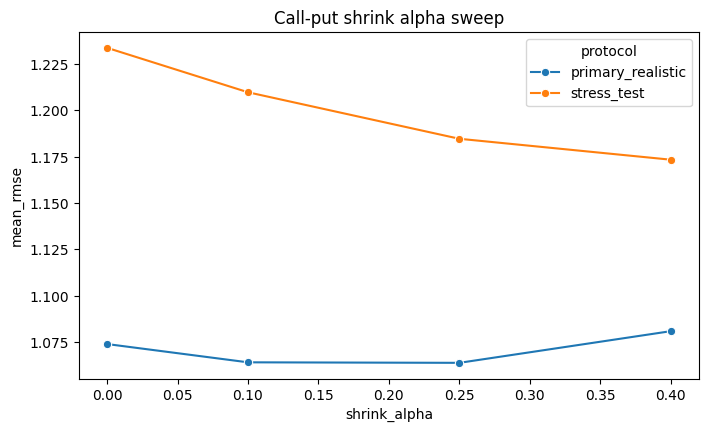

In [29]:
# --- Phase 4 tiny alpha sweep / Cell 3: optional visualization ---

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4.5))
sns.lineplot(
    data=alpha_summary,
    x="alpha",
    y="mean_rmse",
    hue="protocol",
    marker="o",
)
plt.title("Call-put shrink alpha sweep")
plt.ylabel("mean_rmse")
plt.xlabel("shrink_alpha")
plt.show()


## Phase 4 structured surface models: final summary, results, and modeling takeaways

This notebook moves beyond the Phase 3 baselines and asks a more specific modeling question:

**Can we improve IV-surface completion by imposing smoother and more finance-aware same-date structure across moneyness, maturity, and paired call-put information?**

From Phase 3, we already knew that:

- same-date anchor-aware baselines dominate historical-only baselines
- `same_date_linear_interp` is the strongest baseline
- the remaining errors are concentrated in:
  - wings
  - lower-support regions
  - some maturity-specific slices

So Phase 4 focuses on structured same-date surface modeling rather than generic machine learning.

---

## 1. What we tried

We evaluated a sequence of increasingly structured models.

### A. `same_date_linear_interp`
This is the main Phase 3 benchmark carried forward into Phase 4.

For each:

- date
- maturity
- option type

we linearly interpolate IV across visible same-date anchors in moneyness.

Purpose:
- baseline to beat
- strong but simple anchor-aware completion rule

---

### B. `quadratic_smile_logm`
For each:

- date
- maturity
- option type

we fit a quadratic curve in:

- `log(moneyness)`

using visible same-date anchors.

Design:
- use the quadratic fit only when enough anchors are available
- apply it only inside the observed anchor span
- otherwise fall back to `same_date_linear_interp`

Purpose:
- test whether a smooth smile fit improves on piecewise linear interpolation

---

### C. `tv_maturity_interp`
For each:

- date
- moneyness
- option type

we interpolate across maturity in:

- **total variance**

and then convert back to IV for scoring.

Design:
- use only when the target lies inside the observed maturity span
- avoid extrapolation beyond maturity anchors
- otherwise fall back to `same_date_linear_interp`

Purpose:
- test whether maturity-aware structure in total variance improves on same-date interpolation

---

### D. `structured_equal_blend`
This combines:

- `quadratic_smile_logm`
- `tv_maturity_interp`

Rule:
- if both structured predictions are available, average them equally
- if only one is available, use that one
- otherwise fall back to `same_date_linear_interp`

Purpose:
- test whether smile structure and maturity structure are complementary

---

### E. `structured_region_blend`
This is a region-aware version of the blend.

Rule:
- in the **center**, weight the smile model more
- in the **wings**, weight the total-variance maturity model more

Purpose:
- exploit the empirical pattern that:
  - smile fitting helps more in the center
  - maturity interpolation helps more in the wings

---

### F. `structured_region_blend_callput_shrink`
This is the final refinement.

Starting from `structured_region_blend`, if the opposite option is visible at the same:

- date
- moneyness
- maturity

then we shrink the prediction partway toward that observed opposite-option IV.

This is a **soft** consistency adjustment, not a hard equality rule.

Purpose:
- use the strong but imperfect call-put relationship identified in EDA
- test whether paired-node information improves the structured hybrid

---

## 2. Main modeling progression

The Phase 4 performance progression is:

1. `same_date_linear_interp`
2. `quadratic_smile_logm`
3. `tv_maturity_interp`
4. `structured_equal_blend`
5. `structured_region_blend`
6. `structured_region_blend_callput_shrink`

This is the clearest story in the notebook:

- smile-only structure helps
- maturity-aware total-variance interpolation helps more
- combining smile and maturity helps more still
- adding soft call-put shrinkage gives a final additional gain

So the structured improvements are cumulative, not arbitrary.

---

## 3. Main results and what they mean

### A. Smile-only structure helps
`quadratic_smile_logm` improves on `same_date_linear_interp` under both validation protocols.

Interpretation:
- same-date smile smoothness contains real signal
- linear interpolation is strong, but not fully optimal

However, the gain is modest.
So smile-only fitting is helpful, but not sufficient as the main structured answer.

---

### B. Maturity interpolation in total variance helps more
`tv_maturity_interp` improves further and beats both:

- `same_date_linear_interp`
- `quadratic_smile_logm`

Interpretation:
- maturity-aware structure is more valuable than smile-only fitting at this stage
- using **total variance** was the correct representation for maturity modeling

This directly validates one of the key EDA conclusions.

---

### C. The combined structured models are clearly better than either single component
Both:

- `structured_equal_blend`
- `structured_region_blend`

beat the single-structure models.

Interpretation:
- smile structure and maturity structure capture different useful parts of the surface
- they are complementary, not redundant
- combining them is better than choosing only one

This is the central modeling result of Phase 4.

---

### D. Region-aware blending helps slightly
`structured_region_blend` beats `structured_equal_blend`, but only by a small margin.

Interpretation:
- the center-vs-wing distinction is meaningful
- but the main gain comes from combining the two structured signals at all
- the existence of both blend models near the top is more important than the tiny gap between them

---

### E. Soft call-put shrinkage gives one final real improvement
A small shrink toward the visible opposite-option IV improves the current leader under both validation protocols.

Interpretation:
- opposite-option information adds real value
- but it should be used as a **soft cue**, not a hard put-call equality rule
- this is fully consistent with the EDA finding that calls and puts are strongly related, but not identical

---

## 4. What the pooled breakdowns showed

### By region: center vs wing

#### `quadratic_smile_logm`
- strongest in the **center**
- relatively weaker in the **wings**

Interpretation:
- smile fitting helps most where the local smile is well-supported and regular

#### `tv_maturity_interp`
- stronger in the **wings**
- weaker than smile fitting in the center

Interpretation:
- maturity structure becomes especially useful where pure cross-moneyness interpolation struggles

#### Combined structured blends
- preserve the center advantage of smile fitting
- preserve the wing advantage of maturity interpolation

This is exactly why the blended models become the best structured family.

---

### By maturity

The maturity breakdown showed that:

- `2M` benefits strongly from maturity interpolation
- `3M` also improves
- `1M` and `6M` behave more like edge maturities

Interpretation:
- interior maturities gain the most from cross-maturity interpolation
- edge maturities cannot benefit as much from maturity interpolation alone because extrapolation is intentionally avoided

This is a sensible modeling property, not a defect.

---

## 5. Hard-case and support diagnostics

A final diagnostic pass checked whether the Phase 4 gains came only from easy rows or also from harder sparse-support cases.

### What we found
- Most of the gain comes from **non-hard-case / locally supported rows**
- Under the harsher `stress_test` protocol, the structured blend also improves some hard-case rows
- But the main residual weakness of the system remains the low-support / fallback regime

Interpretation:
- Phase 4 materially improves the supported part of the surface
- but sparse-support residuals remain one of the main open problems for Phase 5

This is one of the most important handoff insights into ML.

---

## 6. Source-conditioned diagnostics

We also inspected RMSE by prediction source inside the winning structured blend.

### What we found
The strongest-performing branches were the explicitly structured ones:

- smile-only structured rows
- TV-only structured rows
- blended structured rows

The weakest branch remained:
- the fallback `same_date_linear_interp` path

Interpretation:
- the structured rules themselves are working well
- the main residual weakness is not the structured branches
- the main residual weakness is the rows that still depend on simpler fallback logic

This again points to the main Phase 5 opportunity:
- learn residual structure precisely where the handcrafted structured model still falls back

---

## 7. Calendar monotonicity in total variance

One important Phase 4 question was whether better RMSE came at the cost of worse maturity structure.

The answer is no.

The calendar audit showed:

- all leading models are already very clean in total variance
- `tv_maturity_interp` and `structured_region_blend` are cleaner than `same_date_linear_interp`
- `structured_region_blend` is at least as clean as `tv_maturity_interp`
- residual calendar violations are extremely small

This means the structured leaders are not only more accurate.
They are also maturity-consistent and financially well-behaved.

So there is no immediate need for heavy arbitrage repair or hard monotonicity enforcement at this stage.

---

## 8. Tiny alpha sweep for call-put shrinkage

Because the shrinkage model became the notebook winner, we ran one final tiny grid over the shrink parameter:

- `0.00`
- `0.10`
- `0.25`
- `0.40`

### Result
The best overall choice is:

### `alpha = 0.25`

Interpretation:
- some shrinkage is clearly useful
- too little shrinkage leaves performance on the table
- too much shrinkage begins to over-correct legitimate call-put differences
- `0.25` is the best compromise between the optimistic and conservative validation protocols

So the final call-put shrinkage parameter is locked at:

### `shrink_alpha = 0.25`

---

## 9. Main insights from Phase 4

### Insight 1: Same-date surface structure is multi-dimensional
The surface cannot be fully captured by only:
- moneyness smoothing
or only:
- maturity smoothing

Both matter.

### Insight 2: Total variance is the right maturity modeling space
This was one of the strongest EDA hypotheses, and Phase 4 validates it directly.

Using total variance for maturity interpolation is:
- more accurate
- and more structurally coherent

### Insight 3: The strongest models are structured hybrids
The top models in this notebook are not single-direction models.
They are hybrids combining:
- smile structure
- maturity structure
- and finally opposite-option information

### Insight 4: Opposite-option information adds real value
A soft call-put shrinkage improves the leading structured model under both validation protocols.

This confirms that:
- call and put IVs are strongly related
- but should be used as a soft consistency cue rather than a hard equality constraint

### Insight 5: The main remaining weakness is the fallback regime
The source-conditioned and hard-case diagnostics show that the weakest rows are still the ones that rely on fallback interpolation.

That means the next phase should focus especially on:
- lower-support rows
- fallback-dominated rows
- sparse-support residual structure
- and regions where structured rules alone are not enough

---

## 10. Final Phase 4 conclusion

Phase 4 successfully improves on the Phase 3 benchmark and produces a much stronger structured model family.

The final sequence of improvement is:

- `quadratic_smile_logm` improves on `same_date_linear_interp`
- `tv_maturity_interp` improves further
- `structured_equal_blend` and `structured_region_blend` improve further still
- `structured_region_blend_callput_shrink` becomes the final winner

So the final Phase 4 benchmark to carry forward is:

### `structured_region_blend_callput_shrink`
with
### `shrink_alpha = 0.25`

This is the best structured model in the notebook because it combines:

- same-date smile structure
- maturity interpolation in total variance
- region-aware blending across center vs wing
- soft paired-node call-put shrinkage
- strong RMSE under both validation protocols
- and clean maturity structure in total variance

---

## 11. What this means for Phase 5

Phase 5 should not start from scratch.

Instead, the next modeling question becomes:

**Can supervised / tabular ML improve on the structured hybrid by learning residual structure beyond what the handcrafted structured model already captures?**

The best Phase 4 handoff into Phase 5 is therefore:

- keep `structured_region_blend_callput_shrink` as the main benchmark to beat
- keep `structured_region_blend` as the simpler close structured reference
- use structured-model predictions as candidate features
- focus ML especially on:
  - fallback-dominated rows
  - lower-support regions
  - wings
  - and residual patterns not captured by the structured rules

So the output of Phase 4 is not just a better score.

It is a clearer modeling picture:

- smile structure helps
- maturity structure in total variance helps more
- combining them helps most
- opposite-option information gives a final useful refinement
- and the best current model is a structured hybrid that is both accurate and maturity-consistent

The project can now move into **Phase 5: ML / tabular models** with a strong structured benchmark in place.
